In [1]:
# Allowing dynamic links, hot-reload, to our custom modules
%load_ext autoreload
%autoreload 2

In [2]:
import os, re, sys, traceback, csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sentencepiece as spm

from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

os.getcwd()

'C:\\Beryllium Base\\WORKSPACES\\MTECH\\dl-gen-lyrics\\sandbox'

In [3]:
import generator_core as core
from aspect_midnight import Midnight, Word2Vec_SkipGram, ArrayToDatasetForW2V

In [4]:
create_dataset = False

In [5]:
try:
    # print(core.genius_lyrics.file_name)
    ds_genius = lambda: core.genius_lyrics.open_as_df()

    if create_dataset:
        for ds_batch in ds_genius():
            display(ds_batch.head())
            break
except:
    traceback.print_exc()

In [6]:
try:
    batch_count = 0
    genres = set()
    if create_dataset and False:
        for ds_batch in ds_genius():
            batch_count += 1
            genres.update(ds_batch['tag'].unique())
    else:
        batch_count = 103
        genres = {'rap', 'rb', 'pop', 'country', 'rock', 'misc'}
    print(genres)
    print(batch_count)
except:
    traceback.print_exc()

{'pop', 'country', 'rock', 'rb', 'misc', 'rap'}
103


In [7]:
try:
    total_subset_size = 100000
    total_group_size = total_subset_size // len(genres) + 1
    max_songs_per_artist = 50

    if create_dataset:
        genre_groups = {}
        artist_counts = {}

        pbar = tqdm(total=batch_count)
        for ds_batch in ds_genius():
            pbar.update(1)
            ds_batch = ds_batch.drop(columns=['views', 'features', 'language_cld3', 'language_ft'])
            ds_batch = ds_batch[ds_batch['language'] == 'en'].sample(frac=1)
            ds_batch['length'] = ds_batch['lyrics'].apply(len)
            ds_batch = ds_batch[(ds_batch['length'] >= 1000) & (ds_batch['length'] <= 3000)]

            for genre in genres:
                group = genre_groups.get(genre, pd.DataFrame())
                if len(group) >= total_group_size: continue

                ds_batch = ds_batch[ds_batch['tag'] == genre]
                for artist, a_group in ds_batch.groupby('artist'):
                    existing_count = artist_counts.get(artist, 0)
                    if existing_count >= max_songs_per_artist: continue
                    new_sample = min(len(a_group), max_songs_per_artist - existing_count)
                    subset = a_group.sample(new_sample).drop(columns=['length'])
                    group = pd.concat([group, subset])
                    artist_counts[artist] = existing_count + new_sample

                if len(group) >= total_group_size: group = group.sample(total_group_size)
                genre_groups[genre] = group

            if all([len(group) >= total_group_size for group in genre_groups.values()]): break

        for genre, group in genre_groups.items():
            print(genre, len(group))

        print("Unique Artists", len(artist_counts))
        print("Avg Songs/Artists", np.mean(list(artist_counts.values())))

    else:
        print("misc 16667\nrap 16667\nrb 16667\npop 16667\ncountry 16667\nrock 16667\nUnique Artists 37648\nAvg Songs/Artists 2.8438429664258393")
except:
    traceback.print_exc()

misc 16667
rap 16667
rb 16667
pop 16667
country 16667
rock 16667
Unique Artists 37648
Avg Songs/Artists 2.8438429664258393


In [8]:
try:
    if create_dataset:
        ds_subset = pd.concat(list(genre_groups.values())).sample(frac=1)
        ds_subset.to_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
        display(ds_subset.head())
        del genre_groups
    else:
        ds_subset = pd.read_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
        display(ds_subset.head())
except:
    traceback.print_exc()

,Unnamed: 0,title,tag,artist,year,lyrics,id,language
0,123725,In Memory of W. B. Yeats,misc,W. H. Auden,2013,I\n\nHe disappeared in the dead of winter:\nTh...,134446,en
1,2614099,Sthlm City,pop,Rebecca & Fiona,2018,"[Intro]\nI mean, like, it's okay\nOne day, you...",3931557,en
2,2550228,Fallin 2010,pop,Mozhdah,2010,[Verse 1]\nCan you take it easy\nWhile I make ...,3840000,en
3,3539706,Can the Circle Be Unbroken,country,Johnny Cash,1982,I was standing by the window\nOn one cold and ...,5350667,en
4,2650114,Marijuana,pop,Jah Cure,2019,[Intro: Jah Cure]\nOne puff one draw\nFrees th...,3982786,en


In [9]:
try:
    _t = ds_subset.sample(1)
    print("INDEX: ", _t.index[0])
    print(_t['lyrics'].values[0])
except:
    traceback.print_exc()

INDEX:  60638
                                            "there goes that monster"
                                                        -Lil Wayne

                            slumped outstare a moaning, this gristle torn
                              put song under black wing, a typical cutting
                                              look mama, a roaring
                            What I said was I hardly know you anymore
                                almost seated camera side, glanced
                                  that myth: you ate it up & again
                                    how do you let go of someone
                                              who falls into you
                                urgent urgent this morning's whirr
                                  case studies of girls who seize
                                    who pose the pretty laced set
                                            take it this dollar bill
                              

In [10]:
# There are named speech tags of form "(Devyn)" and "(Simon)"
# Other conventions like "[Hook]" and "[Pre-Hook]"
# Some crazy format issues too like "[Hook ]"
# Sometimes the first line is the song title
# And then there is just text in [] like "[See, everybody ...211 chars total... the same fr]"
# There are also numbered versions like "[Verse 1]"
# 4314672: Wow, there are even URLS like "https://www.rapidbooster.net/". In fact there is no song at all
# 101494 : has "[Verse 1: Michael Jackson]"
# 46815  : has "[Chorus: Slug and Murs]", "[Murs]", "[Slug]"
# 28520  : has "[Frank Sinatra sample]", "[Hook 2X][Frank Sinatra](Kids)", and other text in () and []
# 8889   : has an unclosed [ in the start
# 1459482: has both "(Chorus)" and "Chorus:"
# 2944086: has "[October 31st, 2004]"
# 22005  : has it's verses separated as I, II, III...

In [11]:
try:
    midnight = Midnight(ds_subset)
except:
    traceback.print_exc()

Loaded Cache for Midnight._prepare_ds_data.cached
Loaded Cache for Midnight._get_custom_tokens.cached
Loaded Cache for Midnight._get_genre_dict.cached
Loaded Cache for Midnight._prepare_tfidf.cached
Loaded Cache for Midnight._prepare_vocabulary temp\lyrics_sp.model
Loaded Cache for Midnight._prepare_embedder.cached
Loaded Cache for Midnight._prepare_language_model.cached


In [12]:
try:
    # for sample in ds_subset[ds_subset['id'] == 1856105].itertuples():
    for sample in ds_subset.sample(1).itertuples():
        print("INDEX", sample.id)
        print("ORIGINAL")
        print(sample.lyrics)
        print("PROCESSED")
        print(midnight.clean_text(sample.lyrics))
except:
    traceback.print_exc()

INDEX 2870922
ORIGINAL
[Intro]
Ay, I'm back on that '07 shit, ya hear me
I think I'm the only nigga that can turn opps to fans, ya hear me
Free 9

[Verse]
Me and Nuski swagged up in grad school
Remember when the homicide grabbed you
Boogieman had the trap like a drive thru
The coke is goin' quick like it's fast food
Booka told me D-rose lost his 9-1
Appeal money for them killas when that time come
Sneak dissin' what these goofy niggas dyin' from
One call I'll make my TV it'll slide up
I press 1JB 'cause Zoo was callin'
I press 7 'cause these goofys callin' (Let's get it!)
I fucked yo' bitch and took her Louis shoppin' (Ain't nothin'!)
Fucked yo' bitch and took her Louis shoppin'
I beat my case I keep my pistol on me (Let's get it, L's)
This nigga 'pose to been my man but he was snitchin' on me
And everytime he came around I was grippin' on it
Like fuck yo life I won't think twice and I'll blink you homie
We’ll turn your IG to an obituary
I just took couple of yo homies to a cemetery (L

In [13]:
try:
    print(midnight.custom_tokens)
except:
    traceback.print_exc()

{'<SONG_START>', '<INTERLUDE>', '<INTRO>', '<STANZA>', '<BRIDGE>', '<VERSE>', '<SONG_END>', '<HOOK>', '<OUTRO>', '<CHORUS>'}


In [14]:
try:
    print(midnight.feature_names.shape)
    print(np.random.choice(midnight.feature_names, 10))
except:
    traceback.print_exc()

(50000,)
['redd' 'rewrite' 'masterbate' 'zanny' 'heartbeat' 'hollup' 'howd' 'husks'
 'hymnal' 'bicycle']


In [15]:
try:
    # for sample in ds_subset[ds_subset['id'] == 1856105].itertuples():
    lengths = ds_subset['lyrics'].apply(len)
    print(lengths.min(), lengths.max(), lengths.mean())
    del lengths
    # TODO: 10 random windows of size 20 per song
except:
    traceback.print_exc()

1000 3000 1670.2838243235135


In [16]:
try:
    display(midnight.annotate_text(2))
except:
    traceback.print_exc()

Annotation(text_id=2, genre='pop', keywords=['pull', 'blame', 'love', 'played', 'falling'])

In [17]:
try:
    print("Vocab Size: ", midnight.vocabulary.vocab_size())
    dat = midnight.tokenize_text("pneumonoultramicroscopicsilicovolcanoconiosis")
    print(dat)
except:
    traceback.print_exc()

Vocab Size:  16000
[14617, 11135, 3890, 3445, 10503, 14, 1640, 10636, 14, 7429, 1640, 2981, 8764, 7737, 3402, 626, 12244]


In [32]:
try:
    word2vec = midnight._prepare_embedder()
    print(word2vec)
except:
    traceback.print_exc()

Word2Vec_SkipGram(
  (embeddings): Embedding(16000, 512, max_norm=1.0)
  (linear): Linear(in_features=512, out_features=16000, bias=True)
)


In [43]:
try:
    train_word2vec = True

    if train_word2vec:
        # word2vec.trainer.dataset_fraction = None
        # word2vec.trainer.dataset_length = len(word2vec.trainer.train_dataloader)
        word2vec.trainer.device = 'cuda'
        # for pg in word2vec.trainer.optimizer.param_groups:
        #     pg['lr'] = 0.003
except:
    traceback.print_exc()

In [ ]:
try:
    if train_word2vec:
        word2vec.train_model()
    # CPU Time = 4.11 seconds average
except:
    traceback.print_exc()

Epoch:  0/ 1    Train Loss: 4.68    TTS: 3.69    ETA: 23051.38
Epoch:  0/ 1    Train Loss: 4.62    TTS: 4.49    ETA: 14024.79
Epoch:  0/ 1    Train Loss: 5.35    TTS: 5.25    ETA: 10934.08
Epoch:  0/ 1    Train Loss: 4.66    TTS: 6.04    ETA: 9430.26
Epoch:  0/ 1    Train Loss: 4.87    TTS: 6.83    ETA: 8527.15
Epoch:  0/ 1    Train Loss: 4.98    TTS: 7.61    ETA: 7925.44
Epoch:  0/ 1    Train Loss: 4.72    TTS: 8.42    ETA: 7514.45
Epoch:  0/ 1    Train Loss: 4.86    TTS: 9.21    ETA: 7190.72
Epoch:  0/ 1    Train Loss: 4.96    TTS: 10.04    ETA: 6962.04
Epoch:  0/ 1    Train Loss: 4.68    TTS: 10.85    ETA: 6768.85
Epoch:  0/ 1    Train Loss: 5.21    TTS: 11.65    ETA: 6608.79
Epoch:  0/ 1    Train Loss: 4.96    TTS: 12.45    ETA: 6474.55
Epoch:  0/ 1    Train Loss: 4.92    TTS: 13.27    ETA: 6366.23
Epoch:  0/ 1    Train Loss: 4.82    TTS: 14.06    ETA: 6265.09
Epoch:  0/ 1    Train Loss: 4.56    TTS: 15.67    ETA: 6107.00
Epoch:  0/ 1    Train Loss: 4.69    TTS: 16.43    ETA: 6025.

In [41]:
try:
    if train_word2vec:
        timers = word2vec.trainer.timer.timers
        for key in timers:
            print(key, timers[key].average)
except:
    traceback.print_exc()

train 0.0
_train_step 0.0
train_dataloader 0.014113680268440558
batch 3.740308725302782


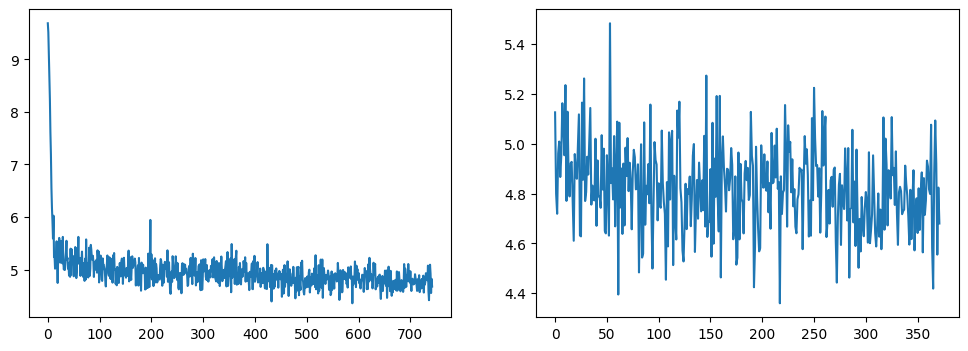

In [42]:
try:
    if train_word2vec:
        loss = word2vec.trainer.loss
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        axs[0].plot(loss['train.batch'])
        axs[1].plot(loss['train.batch'][int(0.5 * len(loss['train.batch'])):])
        plt.show()
except:
    traceback.print_exc()

In [23]:
try:
    if train_word2vec:
        rewrite_embedder_cache = True
        if rewrite_embedder_cache:
            flight = 'Midnight._prepare_embedder.cached'
            for file in ['bone', 'pkl']:
                file = os.path.join('temp', f'{flight}.{file}')
                if os.path.exists(file): os.remove(file)
            core.key_cached('cached', lambda: word2vec, group='Midnight._prepare_embedder')
except:
    traceback.print_exc()

In [28]:
try:
    _embeds_a = midnight.embed_tokens("happy")
    _embeds_b = midnight.embed_tokens("joy")
    _embeds_c = midnight.embed_tokens("sad")
    print((_embeds_a * _embeds_b).sum())
    print((_embeds_a * _embeds_c).sum())
except:
    traceback.print_exc()

0.6403019
0.7390667


In [41]:
try:
    train_language_model = True

    if train_language_model:
        midnight.language_model.trainer.dataset_fraction = None
        midnight.language_model.trainer.dataset_length = len(midnight.language_model.trainer.train_dataloader)
        midnight.language_model.trainer.device = 'cuda'
        # for pg in midnight.language_model.trainer.optimizer.param_groups:
        #     pg['lr'] = 0.0003
except:
    traceback.print_exc()

In [44]:
try:
    if train_language_model:
        midnight.language_model.train_model()
        # CPU 207808s
except:
    traceback.print_exc()

Epoch:  0/ 1    Train Loss: 4.95    TTS: 7.53    ETA: 23530.36
Epoch:  0/ 1    Train Loss: 5.00    TTS: 10.44    ETA: 21746.30
Epoch:  0/ 1    Train Loss: 4.99    TTS: 11.20    ETA: 17491.54
Epoch:  0/ 1    Train Loss: 5.20    TTS: 12.72    ETA: 15890.19
Epoch:  0/ 1    Train Loss: 5.07    TTS: 13.18    ETA: 13715.83
Epoch:  0/ 1    Train Loss: 5.22    TTS: 15.07    ETA: 13438.42
Epoch:  0/ 1    Train Loss: 4.88    TTS: 15.76    ETA: 12296.37
Epoch:  0/ 1    Train Loss: 4.93    TTS: 16.28    ETA: 11288.74
Epoch:  0/ 1    Train Loss: 4.95    TTS: 16.78    ETA: 10472.78
Epoch:  0/ 1    Train Loss: 4.88    TTS: 17.59    ETA: 9977.66
Epoch:  0/ 1    Train Loss: 5.30    TTS: 19.36    ETA: 10066.85
Epoch:  0/ 1    Train Loss: 4.98    TTS: 19.96    ETA: 9579.73
Epoch:  0/ 1    Train Loss: 5.00    TTS: 20.71    ETA: 9224.97
Epoch:  0/ 1    Train Loss: 4.85    TTS: 21.65    ETA: 9000.59
Epoch:  0/ 1    Train Loss: 4.92    TTS: 22.57    ETA: 8795.00
Epoch:  0/ 1    Train Loss: 5.02    TTS: 23.55

Traceback (most recent call last):
  File "C:\Users\mcxiv\AppData\Local\Temp\ipykernel_9924\3279432054.py", line 3, in <module>
    midnight.language_model.train_model()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\aspect_midnight\conditional_lstm_lm.py", line 161, in train_model
    self.trainer.train()
    ~~~~~~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 181, in train
    self._train_step(epoch)
    ~~~~~~~~~~~~~~~~^^^^^^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 24, in _train_step
    loss_data = [collate(x[1]) for x in batch]
            ^^^^^^^^^^^^^^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\_tensor.py", line 631, in backward
    torch.autograd.backward(
    ~~~~~~~~~~~~~~~~~~~~~~~^
        self, gradient, retain_graph, create_graph, inputs=inputs
        ^^^^^^^^^^^^^

In [45]:
try:
    if train_language_model:
        timers = midnight.language_model.trainer.timer.timers
        for key in timers:
            print(key, timers[key].average)
except:
    traceback.print_exc()

train 347.21316619999925
_train_step 347.14727010000024
train_dataloader 0.028360647187929636
batch 3.5018235448132886


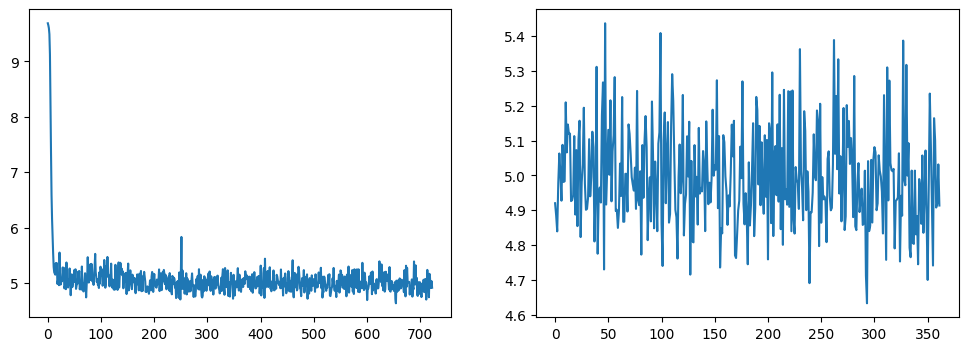

In [46]:
try:
    if train_language_model:
        loss = midnight.language_model.trainer.loss
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        axs[0].plot(loss['train.batch'])
        axs[1].plot(loss['train.batch'][int(0.5 * len(loss['train.batch'])):])
        plt.show()
except:
    traceback.print_exc()

In [47]:
try:
    if train_language_model:
        rewrite_language_model_cache = True
        if rewrite_language_model_cache:
            flight = 'Midnight._prepare_language_model.cached'
            for file in ['bone', 'pkl']:
                file = os.path.join('temp', f'{flight}.{file}')
                if os.path.exists(file): os.remove(file)
            core.key_cached('cached', lambda: midnight.language_model, group='Midnight._prepare_language_model')
            print("Saved")
except:
    traceback.print_exc()

Saved


In [55]:
try:
    print(midnight.inference('pop', 'life goals'))
except:
    traceback.print_exc()

<SONG_ST ⁇ RT>S_RW <_W>NELILI <'O <S_LI < .LI_ totW canW>W on>_ itW a>NENEW my


In [53]:
try:
    print(midnight.tokenize_text("<CHORUS>"))
    print(midnight.custom_tokens)
    print(midnight.genre_to_id.keys())
except:
    traceback.print_exc()

[5, 64, 55, 49, 56, 35, 4]
{'<SONG_END>', '<HOOK>', '<CHORUS>', '<OUTRO>', '<INTRO>', '<VERSE>', '<BRIDGE>', '<SONG_START>', '<INTERLUDE>', '<STANZA>'}
dict_keys(['misc', 'pop', 'country', 'rock', 'rb', 'rap'])
